### ```E-Commerce Sales Analytics```

- The Ecommerce sales data gives you understanding on the products

In [2]:
# We are importing necessary libraries for our case study.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Reading the CSV data
df = pd.read_csv(r"C:\Users\raksh\Downloads\DATA SCIENCE\Python for DataScience\Datafiles\ecommerce_sales_data.csv")

In [4]:
#display the data
df.head()

,Order ID,Customer ID,Gender,Age,Product Category,Product Name,Quantity,Price,Order Date,Payment Method,City,Rating
0,ORD0001,CUST9376,Female,43,Home,Lamp,1,1368.69,07-06-2025,Cash on Delivery,Hyderabad,3
1,ORD0002,CUST3289,Male,57,Toys,Lego Set,5,782.44,11-12-2024,Cash on Delivery,Chennai,5
2,ORD0003,CUST6409,Female,53,Clothing,Jacket,1,3676.18,05-05-2025,Credit Card,Bangalore,4
3,ORD0004,CUST8815,Female,51,Beauty,Perfume,2,4836.37,25-06-2025,Cash on Delivery,Mumbai,5
4,ORD0005,CUST1018,Female,39,Electronics,Smartphone,4,3580.24,25-12-2024,UPI,Kolkata,3


In [5]:
#Checking the dimensions of the data.
df.shape

(100, 12)

```Data Preprocessing```

In [6]:
# for further understanding the statistical summary of data using Describe method.
df.describe()

,Age,Quantity,Price,Rating
count,100.000000,100.00000,100.000000,100.000000
mean,37.720000,2.94000,2428.300600,3.000000
std,12.426007,1.44124,1508.115395,1.392621
min,18.000000,1.00000,118.330000,1.000000
25%,28.000000,2.00000,1130.615000,2.000000
50%,37.500000,3.00000,2160.355000,3.000000
75%,49.000000,4.00000,3743.872500,4.000000
max,60.000000,5.00000,4836.370000,5.000000


- We can see that average age is 37 and lowest is 18, maximum is 60.
- Average quantity is 2.94 with lowest is 1.0 and highest is 5 quantity.
- The average price is 2428 with minimum price of quantity is 118 and maximum price is 4836.

In [7]:
#To get the information about the data of the columns with respect to datatypes.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          100 non-null    str    
 1   Customer ID       100 non-null    str    
 2   Gender            100 non-null    str    
 3   Age               100 non-null    int64  
 4   Product Category  100 non-null    str    
 5   Product Name      100 non-null    str    
 6   Quantity          100 non-null    int64  
 7   Price             100 non-null    float64
 8   Order Date        100 non-null    str    
 9   Payment Method    100 non-null    str    
 10  City              100 non-null    str    
 11  Rating            100 non-null    int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 9.5 KB


In [8]:
# Checking for null values.
df.isnull().sum()

Order ID            0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Product Name        0
Quantity            0
Price               0
Order Date          0
Payment Method      0
City                0
Rating              0
dtype: int64

- The above data doesn't have any null values in the data. We are good with the further analysis.

In [9]:
df.nunique()

Order ID            100
Customer ID          98
Gender                2
Age                  39
Product Category      6
Product Name         20
Quantity              5
Price               100
Order Date           88
Payment Method        4
City                  6
Rating                5
dtype: int64

In [10]:
#To see the actual duplicate rows present in the data.
df[df.duplicated()]

,Order ID,Customer ID,Gender,Age,Product Category,Product Name,Quantity,Price,Order Date,Payment Method,City,Rating


- The above cell we can confrim that there are no duplicate rows in the dataset.

In [25]:
df[df.duplicated(subset='Customer ID', keep=False)]

#In the above duplicated column we can see customer ID for for items are duplicate but the order ID is different, as customer ID is less priority to our analysis as we use Order Id for further analysis.

,Order ID,Customer ID,Gender,Age,Product Category,Product Name,Quantity,Price,Order Date,Payment Method,City,Rating
2,ORD0003,CUST6409,Female,53,Clothing,Jacket,1,3676.18,05-05-2025,Credit Card,Bangalore,4
51,ORD0052,CUST3480,Female,44,Home,Curtains,1,3400.36,20-03-2025,Credit Card,Chennai,4
52,ORD0053,CUST3480,Male,20,Home,Lamp,1,597.25,04-07-2025,UPI,Kolkata,3
82,ORD0083,CUST6409,Female,28,Clothing,T-Shirt,4,2358.38,24-04-2025,Cash on Delivery,Hyderabad,4


Observations:
- We can find that the customer behaviour.
- We can see that Customer ID is only unique value, we can consider it by dropping as it won't be that priority to our analysis.


In [11]:
df.drop('Customer ID', axis=1)

,Order ID,Gender,Age,Product Category,Product Name,Quantity,Price,Order Date,Payment Method,City,Rating
0,ORD0001,Female,43,Home,Lamp,1,1368.69,07-06-2025,Cash on Delivery,Hyderabad,3
1,ORD0002,Male,57,Toys,Lego Set,5,782.44,11-12-2024,Cash on Delivery,Chennai,5
2,ORD0003,Female,53,Clothing,Jacket,1,3676.18,05-05-2025,Credit Card,Bangalore,4
3,ORD0004,Female,51,Beauty,Perfume,2,4836.37,25-06-2025,Cash on Delivery,Mumbai,5
4,ORD0005,Female,39,Electronics,Smartphone,4,3580.24,25-12-2024,UPI,Kolkata,3
...,...,...,...,...,...,...,...,...,...,...,...
95,ORD0096,Male,49,Home,Curtains,4,292.82,10-02-2025,UPI,Delhi,3
96,ORD0097,Male,36,Beauty,Face Cream,4,625.70,04-01-2025,Netbanking,Chennai,5
97,ORD0098,Male,57,Home,Curtains,3,1435.48,19-08-2024,Credit Card,Delhi,4
98,ORD0099,Female,21,Clothing,Jeans,3,4410.96,15-08-2024,Credit Card,Hyderabad,3


```Exploratory Data Analysis [EDA]```

Gender
Female    51
Male      49
Name: count, dtype: int64


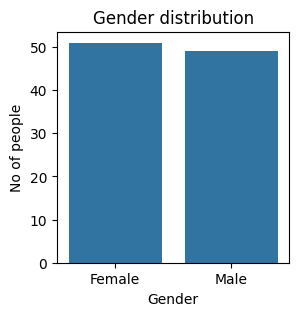

In [12]:
# What is the Gender Distribution
gender_count = df['Gender'].value_counts()
print(gender_count)

plt.figure(figsize=(3,3))
sns.barplot(x=gender_count.index,y=gender_count.values)
plt.ylabel('No of people')
plt.title('Gender distribution')
plt.show()

In [13]:
# What are the product category and how many each are present.

#We can find that there are 6 unique products
df['Product Category'].nunique()

# We can see that distribution on orders for each products.
df['Product Category'].value_counts()

Product Category
Clothing       21
Electronics    19
Books          18
Home           17
Beauty         13
Toys           12
Name: count, dtype: int64

Observations:
- We can conclude that top most orders are from clothing, electronics & Books.

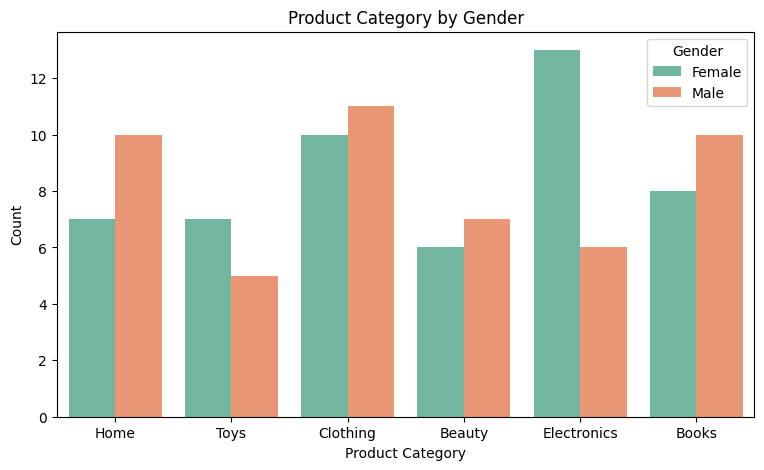

In [14]:
# What are the product category distribution based on gender.

plt.figure(figsize=(9,5))
sns.countplot(x='Product Category', hue='Gender', data=df, palette='Set2')
plt.title('Product Category by Gender')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()

Observation:
- We can conclude that the Feamle are mostly in Clothing & Electronics.
- Males are mostly in Clothing, Home, & Books.
- Ideal look says that Male and Female are interest in Clothing (Trend Patterns)

In [15]:
# Average money spent on products.

avg_spent = df['Price'].mean()
print(avg_spent)

df.groupby('Product Category')['Price'].mean()

2428.3006000000005


Product Category
Beauty         2618.192308
Books          2396.831667
Clothing       2261.636667
Electronics    2299.012632
Home           2789.844706
Toys           2253.968333
Name: Price, dtype: float64

In [31]:
# Payment mode usage on most orders

payment_count = df['Payment Method'].value_counts()

df.groupby('Order ID')['Payment Method'].value_counts()


Order ID  Payment Method  
ORD0001   Cash on Delivery    1
ORD0002   Cash on Delivery    1
ORD0003   Credit Card         1
ORD0004   Cash on Delivery    1
ORD0005   UPI                 1
                             ..
ORD0096   UPI                 1
ORD0097   Netbanking          1
ORD0098   Credit Card         1
ORD0099   Credit Card         1
ORD0100   UPI                 1
Name: count, Length: 100, dtype: int64

In [21]:
df

,Order ID,Customer ID,Gender,Age,Product Category,Product Name,Quantity,Price,Order Date,Payment Method,City,Rating
0,ORD0001,CUST9376,Female,43,Home,Lamp,1,1368.69,07-06-2025,Cash on Delivery,Hyderabad,3
1,ORD0002,CUST3289,Male,57,Toys,Lego Set,5,782.44,11-12-2024,Cash on Delivery,Chennai,5
2,ORD0003,CUST6409,Female,53,Clothing,Jacket,1,3676.18,05-05-2025,Credit Card,Bangalore,4
3,ORD0004,CUST8815,Female,51,Beauty,Perfume,2,4836.37,25-06-2025,Cash on Delivery,Mumbai,5
4,ORD0005,CUST1018,Female,39,Electronics,Smartphone,4,3580.24,25-12-2024,UPI,Kolkata,3
...,...,...,...,...,...,...,...,...,...,...,...,...
95,ORD0096,CUST3955,Male,49,Home,Curtains,4,292.82,10-02-2025,UPI,Delhi,3
96,ORD0097,CUST5677,Male,36,Beauty,Face Cream,4,625.70,04-01-2025,Netbanking,Chennai,5
97,ORD0098,CUST1271,Male,57,Home,Curtains,3,1435.48,19-08-2024,Credit Card,Delhi,4
98,ORD0099,CUST1105,Female,21,Clothing,Jeans,3,4410.96,15-08-2024,Credit Card,Hyderabad,3
